<a href="https://colab.research.google.com/github/insyirahazman/Collaborative-Filtering-Algorithms-in-Recommendation-Systems/blob/main/SVD_MatrixFactorization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matrix Factorization using SVD SGD

In [11]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Load MovieLens 100K dataset
ratings = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/TDA Project/ml-100k/u.data",
    sep="\t",
    header=None,
    usecols=[0, 1, 2],
    names=["user_id", "movie_id", "rating"]
)

ratings.head()

,user_id,movie_id,rating
0,196,242,3
1,186,302,3
2,22,377,1
3,244,51,2
4,166,346,1


In [3]:
ratings.shape

(100000, 3)

In [4]:
input_size = 20000

data_subset = ratings.head(input_size).copy()

train_data, test_data = train_test_split(
    data_subset,
    test_size=0.30,
    random_state=42
)

print("Total ratings:", len(data_subset))
print("Training ratings:", len(train_data))
print("Testing ratings:", len(test_data))

Total ratings: 20000
Training ratings: 14000
Testing ratings: 6000


In [5]:
# svd parameters
K = 20
epochs = 20
learning_rate = 0.005
regularization = 0.02
random_state = 42

In [6]:
# prepare user and movie index mapping
np.random.seed(random_state)

global_mean = train_data["rating"].mean()

user_ids = train_data["user_id"].unique()
movie_ids = train_data["movie_id"].unique()

user_to_index = {user_id: index for index, user_id in enumerate(user_ids)}
movie_to_index = {movie_id: index for index, movie_id in enumerate(movie_ids)}

n_users = len(user_ids)
n_movies = len(movie_ids)

print("Number of users:", n_users)
print("Number of movies:", n_movies)
print("Global mean rating:", global_mean)

Number of users: 459
Number of movies: 1338
Global mean rating: 3.532142857142857


In [7]:
user_factors = np.random.normal(0, 0.1, (n_users, K))
movie_factors = np.random.normal(0, 0.1, (n_movies, K))

user_bias = np.zeros(n_users)
movie_bias = np.zeros(n_movies)

print("User factor matrix shape:", user_factors.shape)
print("Movie factor matrix shape:", movie_factors.shape)

User factor matrix shape: (459, 20)
Movie factor matrix shape: (1338, 20)


In [8]:
# training
training_start = time.perf_counter()

for epoch in range(epochs):
    shuffled_data = train_data.sample(frac=1, random_state=random_state + epoch)

    for row in shuffled_data.itertuples(index=False):
        user_id = row.user_id
        movie_id = row.movie_id
        actual_rating = row.rating

        u = user_to_index[user_id]
        i = movie_to_index[movie_id]

        predicted_rating = (
            global_mean
            + user_bias[u]
            + movie_bias[i]
            + np.dot(user_factors[u], movie_factors[i])
        )

        error = actual_rating - predicted_rating

        old_user_factor = user_factors[u].copy()
        old_movie_factor = movie_factors[i].copy()

        user_bias[u] = user_bias[u] + learning_rate * (
            error - regularization * user_bias[u]
        )

        movie_bias[i] = movie_bias[i] + learning_rate * (
            error - regularization * movie_bias[i]
        )

        user_factors[u] = user_factors[u] + learning_rate * (
            error * old_movie_factor - regularization * old_user_factor
        )

        movie_factors[i] = movie_factors[i] + learning_rate * (
            error * old_user_factor - regularization * old_movie_factor
        )

    print("Epoch", epoch + 1, "completed")

training_end = time.perf_counter()

training_time_ms = (training_end - training_start) * 1000

print("Training time (ms):", round(training_time_ms, 4))

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Training time (ms): 10347.094


In [9]:
# test prediction and calculate rmse mae
prediction_start = time.perf_counter()

actual_ratings = []
predicted_ratings = []

for row in test_data.itertuples(index=False):
    user_id = row.user_id
    movie_id = row.movie_id
    actual_rating = row.rating

    if user_id in user_to_index and movie_id in movie_to_index:
        u = user_to_index[user_id]
        i = movie_to_index[movie_id]

        predicted_rating = (
            global_mean
            + user_bias[u]
            + movie_bias[i]
            + np.dot(user_factors[u], movie_factors[i])
        )
    else:
        predicted_rating = global_mean

    predicted_rating = min(5, max(1, predicted_rating))

    actual_ratings.append(actual_rating)
    predicted_ratings.append(predicted_rating)

prediction_end = time.perf_counter()

prediction_time_ms = (prediction_end - prediction_start) * 1000
execution_time_ms = training_time_ms + prediction_time_ms

rmse = sqrt(mean_squared_error(actual_ratings, predicted_ratings))
mae = mean_absolute_error(actual_ratings, predicted_ratings)

print("Input Size:", input_size)
print("Execution Time (ms):", round(execution_time_ms, 4))
print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))

Input Size: 20000
Execution Time (ms): 10368.0323
RMSE: 1.004
MAE: 0.7991


In [12]:
movie_similarity_matrix = cosine_similarity(movie_factors)

movie_similarity_df = pd.DataFrame(
    movie_similarity_matrix,
    index=movie_ids,
    columns=movie_ids
)

movie_similarity_df.head()

,1016,877,370,253,2,229,78,846,82,99,...,1470,1310,777,1555,439,1181,1166,1563,1307,958
1016,1.000000,0.322147,-0.216923,-0.616718,-0.337378,-0.087201,-0.087184,0.287081,-0.035632,-0.030268,...,0.307729,-0.381617,0.486935,0.121588,-0.079260,0.352215,-0.200612,0.259112,-0.242912,-0.241994
877,0.322147,1.000000,-0.041646,-0.083267,-0.147905,0.202563,-0.116648,-0.076308,-0.246222,-0.197224,...,0.229927,-0.026252,0.119574,0.013155,-0.073050,0.038530,-0.277049,-0.134460,0.245608,-0.005831
370,-0.216923,-0.041646,1.000000,0.160838,0.194554,0.353795,0.285558,0.250482,-0.155809,-0.437216,...,-0.386010,0.353602,-0.113274,-0.012151,0.137954,0.069362,0.042289,0.074226,0.333711,0.080294
253,-0.616718,-0.083267,0.160838,1.000000,0.140342,0.139679,-0.178288,-0.307378,-0.112492,0.009382,...,-0.418581,0.340775,-0.396037,-0.529659,0.251417,-0.351792,0.128096,-0.316583,0.149828,0.080330
2,-0.337378,-0.147905,0.194554,0.140342,1.000000,-0.071618,0.301229,-0.012699,0.335359,0.029111,...,-0.322275,0.250974,-0.003929,-0.356924,0.183616,-0.066205,0.016905,-0.132342,0.108853,0.155315


In [13]:
target_movie_id = 50

if target_movie_id in movie_similarity_df.index:
    similar_movies = movie_similarity_df[target_movie_id].sort_values(ascending=False)
    similar_movies.head(10)
else:
    print("Movie ID not found in training data.")

In [14]:
input_sizes = [10000, 20000, 40000, 60000, 80000, 100000]

K = 20
epochs = 20
learning_rate = 0.005
regularization = 0.02
random_state = 42

results = []

for input_size in input_sizes:
    print("\nRunning SVD for", input_size, "ratings")

    data_subset = ratings.head(input_size).copy()

    train_data, test_data = train_test_split(
        data_subset,
        test_size=0.30,
        random_state=42
    )

    np.random.seed(random_state)

    global_mean = train_data["rating"].mean()

    user_ids = train_data["user_id"].unique()
    movie_ids = train_data["movie_id"].unique()

    user_to_index = {user_id: index for index, user_id in enumerate(user_ids)}
    movie_to_index = {movie_id: index for index, movie_id in enumerate(movie_ids)}

    n_users = len(user_ids)
    n_movies = len(movie_ids)

    user_factors = np.random.normal(0, 0.1, (n_users, K))
    movie_factors = np.random.normal(0, 0.1, (n_movies, K))

    user_bias = np.zeros(n_users)
    movie_bias = np.zeros(n_movies)

    training_start = time.perf_counter()

    for epoch in range(epochs):
        shuffled_data = train_data.sample(frac=1, random_state=random_state + epoch)

        for row in shuffled_data.itertuples(index=False):
            user_id = row.user_id
            movie_id = row.movie_id
            actual_rating = row.rating

            u = user_to_index[user_id]
            i = movie_to_index[movie_id]

            predicted_rating = (
                global_mean
                + user_bias[u]
                + movie_bias[i]
                + np.dot(user_factors[u], movie_factors[i])
            )

            error = actual_rating - predicted_rating

            old_user_factor = user_factors[u].copy()
            old_movie_factor = movie_factors[i].copy()

            user_bias[u] = user_bias[u] + learning_rate * (
                error - regularization * user_bias[u]
            )

            movie_bias[i] = movie_bias[i] + learning_rate * (
                error - regularization * movie_bias[i]
            )

            user_factors[u] = user_factors[u] + learning_rate * (
                error * old_movie_factor - regularization * old_user_factor
            )

            movie_factors[i] = movie_factors[i] + learning_rate * (
                error * old_user_factor - regularization * old_movie_factor
            )

    training_end = time.perf_counter()
    training_time_ms = (training_end - training_start) * 1000

    prediction_start = time.perf_counter()

    actual_ratings = []
    predicted_ratings = []

    for row in test_data.itertuples(index=False):
        user_id = row.user_id
        movie_id = row.movie_id
        actual_rating = row.rating

        if user_id in user_to_index and movie_id in movie_to_index:
            u = user_to_index[user_id]
            i = movie_to_index[movie_id]

            predicted_rating = (
                global_mean
                + user_bias[u]
                + movie_bias[i]
                + np.dot(user_factors[u], movie_factors[i])
            )
        else:
            predicted_rating = global_mean

        predicted_rating = min(5, max(1, predicted_rating))

        actual_ratings.append(actual_rating)
        predicted_ratings.append(predicted_rating)

    prediction_end = time.perf_counter()
    prediction_time_ms = (prediction_end - prediction_start) * 1000

    execution_time_ms = training_time_ms + prediction_time_ms

    rmse = sqrt(mean_squared_error(actual_ratings, predicted_ratings))
    mae = mean_absolute_error(actual_ratings, predicted_ratings)

    results.append({
        "Input Size": input_size,
        "Execution Time (ms)": round(execution_time_ms, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4)
    })

    print("Done:", input_size)
    print("Execution Time (ms):", round(execution_time_ms, 4))
    print("RMSE:", round(rmse, 4))
    print("MAE:", round(mae, 4))

results_df = pd.DataFrame(results)
results_df


Running SVD for 10000 ratings
Done: 10000
Execution Time (ms): 2607.0581
RMSE: 1.0041
MAE: 0.797

Running SVD for 20000 ratings
Done: 20000
Execution Time (ms): 4093.8321
RMSE: 1.004
MAE: 0.7991

Running SVD for 40000 ratings
Done: 40000
Execution Time (ms): 9414.0876
RMSE: 0.9754
MAE: 0.7715

Running SVD for 60000 ratings
Done: 60000
Execution Time (ms): 13702.859
RMSE: 0.9583
MAE: 0.7575

Running SVD for 80000 ratings
Done: 80000
Execution Time (ms): 18408.3381
RMSE: 0.9521
MAE: 0.7483

Running SVD for 100000 ratings
Done: 100000
Execution Time (ms): 20983.5233
RMSE: 0.9404
MAE: 0.742


,Input Size,Execution Time (ms),RMSE,MAE
0,10000,2607.0581,1.0041,0.7970
1,20000,4093.8321,1.0040,0.7991
2,40000,9414.0876,0.9754,0.7715
3,60000,13702.8590,0.9583,0.7575
4,80000,18408.3381,0.9521,0.7483
5,100000,20983.5233,0.9404,0.7420


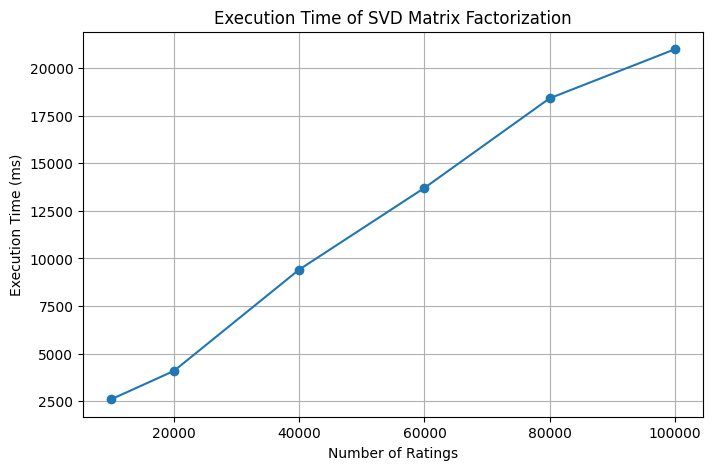

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Input Size"],
    results_df["Execution Time (ms)"],
    marker="o"
)

plt.xlabel("Number of Ratings")
plt.ylabel("Execution Time (ms)")
plt.title("Execution Time of SVD Matrix Factorization")
plt.grid(True)

plt.show()